# 02 — Data Preprocessing
**Project:** California Property Close Price Prediction — IDX Exchange SU26
**Author:** Anvith Mulpuri
**Week:** 3 of 12
**Input:** 7 months of CRMLS SFR sold data (from `01_exploration.ipynb` findings)
**Field reference:** Trestle Property Fields metadata

---

## v2 Update — Leakage-Safe Restructuring

This notebook was restructured to fix two issues flagged against the IDX Exchange AVM Data
Science Best Practices doc:

1. **Outlier thresholds** (ClosePrice percentiles) are now learned from the **training set
   only** and applied as frozen cutoffs to test — never recomputed on test data.
2. **The train/test split now happens immediately after structural row drops** (Section 2),
   *before* any imputation, feature engineering, or encoding. Every statistic used downstream
   (medians, modes, flooring-type frequency, skew checks) is now fit on `train_df` only and
   applied unchanged to `test_df` — matching the same discipline already used for target
   encoding and scaling.
3. Per the leakage audit: `DaysOnMarket` and `PriceReductionYN` are now excluded from the
   model's candidate feature list, alongside the already-excluded `ListPrice`/`OriginalListPrice`.

## Notebook Goals
- Load raw data and re-apply the SFR filter
- Drop structural row errors, then split into train/test **immediately**
- Learn outlier thresholds from train only; apply frozen cutoffs to both splits
- Handle missing values with train-fit statistics applied to both splits
- Engineer derived features (train-fit where any statistic/frequency is involved)
- Encode categorical fields to numeric representations (train-fit)
- Normalize/scale numerical features (train-fit)
- Save both the baseline (no engineered features) and engineered tiers, both leakage-safe

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

In [2]:
# ── Data path ────────────────────────────────────────────────────
# CSVs are stored locally and gitignored. See data-loading-guide.md.
DATA_DIR = Path.home()  # adjust if moved

FILE_MONTHS = [
    'CRMLSSold202511.csv',   # November 2025
    'CRMLSSold202512.csv',   # December 2025
    'CRMLSSold202601.csv',   # January 2026
    'CRMLSSold202602.csv',   # February 2026
    'CRMLSSold202603.csv',   # March 2026
    'CRMLSSold202604.csv',   # April 2026
    'CRMLSSold202605.csv',   # May 2026  <- held-out test month
]

frames = []
for fname in FILE_MONTHS:
    df_month = pd.read_csv(DATA_DIR / fname, low_memory=False)
    df_month['_source_file'] = fname
    frames.append(df_month)

raw = pd.concat(frames, ignore_index=True)
print(f'Total rows loaded (all PropertyTypes): {len(raw):,}')

Total rows loaded (all PropertyTypes): 143,492


In [3]:
# ── Apply project filter ─────────────────────────────────────────
df = raw[
    (raw['PropertyType'] == 'Residential') &
    (raw['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(f'Rows after SFR filter: {len(df):,}')

# Parse dates
for col in ['CloseDate', 'ListingContractDate', 'PurchaseContractDate']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['CloseYearMonth'] = df['CloseDate'].dt.to_period('M')
df['CloseMonth']     = df['CloseDate'].dt.month

Rows after SFR filter: 71,466


---
## 1. Drop Fully-Null & Unusable Fields

Per the Week 2 field audit, these Trestle fields are 100% null in this CRMLS extract, or are
otherwise unusable (freeform text, redundant, or too sparse to impute reliably). They are
dropped before any further processing.

In [4]:
# Fields confirmed 100% null in this extract (Week 2 audit)
FULLY_NULL_FIELDS = [
    'AboveGradeFinishedArea',
    'BelowGradeFinishedArea',
    'BuildingAreaTotal',
    'TaxAnnualAmount',
    'CoveredSpaces',
    'FireplacesTotal',          # use FireplaceYN instead
    'BusinessType',             # not applicable to SFR
    'ElementarySchoolDistrict',
    'MiddleOrJuniorSchoolDistrict',
]

# Additional fields dropped for sparsity / redundancy (not 100% null, but unusable)
SPARSE_OR_REDUNDANT_FIELDS = [
    'WaterfrontYN',             # 99.9% null
    'BasementYN',               # 97.6% null
    'ElementarySchool',         # 87.3% null
    'MiddleOrJuniorSchool',     # 87.2% null
    'HighSchool',               # 83.2% null -- HighSchoolDistrict preferred
    'LotSizeAcres',             # redundant with LotSizeSquareFeet
    'LotSizeArea',              # redundant with LotSizeSquareFeet
    'LotSizeDimensions',        # freeform String 150 -- not modelable
    'MainLevelBedrooms',        # 39.0% null; overlaps BedroomsTotal
]

DROP_FIELDS = FULLY_NULL_FIELDS + SPARSE_OR_REDUNDANT_FIELDS
DROP_FIELDS = [c for c in DROP_FIELDS if c in df.columns]

df.drop(columns=DROP_FIELDS, inplace=True)
print(f'Dropped {len(DROP_FIELDS)} fields.')
print(f'Remaining columns: {df.shape[1]}')

Dropped 18 fields.
Remaining columns: 63


---
## 2. Drop Structural Row Errors (Hard Rules Only)

Only universal, non-statistical row-level errors are dropped here — rules that don't depend
on any learned threshold and therefore can't leak between train and test. `LivingArea == 0`
is a structural impossibility (a home can't have zero square feet), not a statistical outlier,
so it's handled as a fixed rule at this stage.

**ClosePrice outlier removal is intentionally NOT done here** — see Section 4, where
percentile thresholds are learned from the training set only, after the split.

In [5]:
# NOTE: ClosePrice > $10M (288 records) and BedroomsTotal == 0 (31 records) are
# NOT dropped here -- they are legitimate (if rare) transactions. They will be
# addressed via log-transformation (price) and left as-is (bedrooms) rather than removal.

before = len(df)

# LivingArea == 0 -- structural data error, cannot compute PricePerSqFt or size features.
# This is a hard rule (not a learned statistic), so applying it pre-split is leakage-safe.
df = df[df['LivingArea'] > 0]

after = len(df)
print(f'Rows before structural drop: {before:,}')
print(f'Rows after structural drop:  {after:,}')
print(f'Rows dropped (LivingArea==0): {before - after}')

Rows before structural drop: 71,466
Rows after structural drop:  71,412
Rows dropped (LivingArea==0): 54


---
## 3. Handle Missing Values

Each remaining field with nulls is handled per the Week 2 field audit decision table.
Strategy is one of: **impute** (fill with a sensible default), **flag** (create a
missing-indicator column, useful when missingness itself may be informative), or
**leave for Week 6** (school district, to be filled via spatial join).

In [6]:
# Confirm available months in chronological order
available_months = sorted(df['CloseYearMonth'].unique())
print('Available months (chronological):')
for m in available_months:
    print(f'  {m}  ({(df["CloseYearMonth"]==m).sum():,} rows)')

TEST_MONTH = available_months[-1]   # May 2026
print(f'\nTest month (most recent): {TEST_MONTH}')

Available months (chronological):
  2025-11  (9,734 rows)
  2025-12  (10,447 rows)
  2026-01  (7,474 rows)
  2026-02  (8,547 rows)
  2026-03  (11,174 rows)
  2026-04  (12,021 rows)
  2026-05  (12,015 rows)

Test month (most recent): 2026-05


In [7]:
def build_train_test_split(df, test_month, window_x, date_col='CloseYearMonth'):
    '''
    Build a train/test split where:
      - test set  = the single most recent month (test_month)
      - train set = the X months immediately preceding test_month

    window_x is intentionally a parameter, not hardcoded, so that different
    training window lengths can be experimented with in Week 4+ to find the
    value of X that yields the best validation performance.
    '''
    available = sorted(df[date_col].unique())
    test_idx = available.index(test_month)

    if test_idx - window_x < 0:
        raise ValueError(
            f'Requested window_x={window_x} months, but only {test_idx} months '
            f'are available before {test_month}.'
        )

    train_months = available[test_idx - window_x: test_idx]

    train_df = df[df[date_col].isin(train_months)].copy()
    test_df  = df[df[date_col] == test_month].copy()

    return train_df, test_df, train_months

In [8]:
# Build the split with the MAXIMUM available window (X=6) as a starting point.
# The optimal X will be determined experimentally in Week 4 by comparing model
# performance across several window lengths (e.g. X=2, 3, 4, 5, 6).
X_WINDOW = 6

train_df, test_df, train_months = build_train_test_split(df, TEST_MONTH, X_WINDOW)

print(f'Training window (X={X_WINDOW} months): {train_months}')
print(f'Training set size: {len(train_df):,} rows')
print(f'Test set size    : {len(test_df):,} rows (month = {TEST_MONTH})')

# From this point forward, sfr is no longer used directly -- all cleaning,
# imputation, and engineering operates on train_df / test_df independently,
# with any learned statistic fit on train_df only.

Training window (X=6 months): [Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]
Training set size: 59,397 rows
Test set size    : 12,015 rows (month = 2026-05)


In [9]:
# ── Sanity check across several candidate window lengths ─────────
# This does not select the final X (that happens with actual model evaluation
# in Week 4) -- it simply confirms every candidate window is valid and shows
# how training set size changes with X.
print('Training set size for each candidate window length X:')
for x in range(1, 7):
    try:
        _train, _test, _months = build_train_test_split(df, TEST_MONTH, x)
        print(f'  X={x}: {len(_train):>6,} training rows  |  months = {_months}')
    except ValueError as e:
        print(f'  X={x}: {e}')

Training set size for each candidate window length X:
  X=1: 12,021 training rows  |  months = [Period('2026-04', 'M')]
  X=2: 23,195 training rows  |  months = [Period('2026-03', 'M'), Period('2026-04', 'M')]
  X=3: 31,742 training rows  |  months = [Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]
  X=4: 39,216 training rows  |  months = [Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]
  X=5: 49,663 training rows  |  months = [Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]
  X=6: 59,397 training rows  |  months = [Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]


---
## 4. Outlier Thresholds — Learned From Training Data Only

Per AVM best practices: compute the 0.5th and 99.5th percentile `ClosePrice` thresholds
using **the training set only**, then apply those exact, frozen cutoffs to the test set.
The test set's own percentiles are never recomputed or substituted.

In [10]:
# ── ClosePrice outlier thresholds -- learned from TRAIN only ─────
price_low_cutoff  = train_df['ClosePrice'].quantile(0.005)
price_high_cutoff = train_df['ClosePrice'].quantile(0.995)

print(f'ClosePrice outlier thresholds (learned from TRAIN only):')
print(f'  0.5th percentile:  ${price_low_cutoff:,.0f}')
print(f'  99.5th percentile: ${price_high_cutoff:,.0f}')

before_train, before_test = len(train_df), len(test_df)

# Apply identical frozen cutoffs to both splits
train_df = train_df[
    (train_df['ClosePrice'] >= price_low_cutoff) &
    (train_df['ClosePrice'] <= price_high_cutoff)
].copy()

test_df = test_df[
    (test_df['ClosePrice'] >= price_low_cutoff) &
    (test_df['ClosePrice'] <= price_high_cutoff)
].copy()

print(f'\nTrain: {before_train:,} -> {len(train_df):,} rows ({before_train - len(train_df)} dropped)')
print(f'Test:  {before_test:,} -> {len(test_df):,} rows ({before_test - len(test_df)} dropped)')

ClosePrice outlier thresholds (learned from TRAIN only):
  0.5th percentile:  $184,980
  99.5th percentile: $9,150,000

Train: 59,397 -> 58,805 rows (592 dropped)
Test:  12,015 -> 11,909 rows (106 dropped)


---
## 5. Handle Missing Values — Fit on Train, Applied to Both

Constant-value imputation (booleans -> `False`, counts -> `0`, categorical placeholders
-> `'Unknown'`/`'None'`) carries no leakage risk regardless of split, since the fill value
doesn't depend on the data's distribution. Those cells apply identically to `train_df` and
`test_df`.

**Data-derived imputations** (medians, modes) are fit on `train_df` only, and the learned
value is applied to both splits — exactly like the target encoding and scaling already did
in the previous version of this notebook.

In [11]:
# ── Boolean amenity fields -- impute False (constant; no leakage risk) ──
BOOLEAN_IMPUTE_FALSE = [
    'PoolPrivateYN', 'ViewYN', 'FireplaceYN',
    'AttachedGarageYN', 'NewConstructionYN',
]

for col in BOOLEAN_IMPUTE_FALSE:
    if col in train_df.columns:
        n_null_train = train_df[col].isna().sum()
        n_null_test  = test_df[col].isna().sum()
        train_df[col] = train_df[col].fillna(False)
        test_df[col]  = test_df[col].fillna(False)
        print(f'{col}: imputed {n_null_train:,} (train) / {n_null_test:,} (test) nulls -> False')

PoolPrivateYN: imputed 4,421 (train) / 1,033 (test) nulls -> False
ViewYN: imputed 5,059 (train) / 1,138 (test) nulls -> False
FireplaceYN: imputed 45 (train) / 10 (test) nulls -> False
AttachedGarageYN: imputed 7,014 (train) / 1,386 (test) nulls -> False
NewConstructionYN: imputed 4,434 (train) / 935 (test) nulls -> False


/var/folders/_t/ms_9wggj1s1d3vr5j_zzp07c0000gn/T/ipykernel_39542/1097803638.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df[col] = train_df[col].fillna(False)
/var/folders/_t/ms_9wggj1s1d3vr5j_zzp07c0000gn/T/ipykernel_39542/1097803638.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df[col]  = test_df[col].fillna(False)


In [12]:
# ── GarageSpaces / ParkingTotal -- impute 0 (constant) ───────────
for col in ['GarageSpaces', 'ParkingTotal']:
    if col in train_df.columns:
        n_null_train = train_df[col].isna().sum()
        n_null_test  = test_df[col].isna().sum()
        train_df[col] = train_df[col].fillna(0)
        test_df[col]  = test_df[col].fillna(0)
        print(f'{col}: imputed {n_null_train:,} (train) / {n_null_test:,} (test) nulls -> 0')

GarageSpaces: imputed 2,173 (train) / 458 (test) nulls -> 0
ParkingTotal: imputed 0 (train) / 0 (test) nulls -> 0


In [13]:
# ── AssociationFee / AssociationFeeFrequency -- impute no-HOA (constant) ──
n_null_train = train_df['AssociationFee'].isna().sum()
n_null_test  = test_df['AssociationFee'].isna().sum()
train_df['AssociationFee'] = train_df['AssociationFee'].fillna(0)
test_df['AssociationFee']  = test_df['AssociationFee'].fillna(0)
train_df['AssociationFeeFrequency'] = train_df['AssociationFeeFrequency'].fillna('None')
test_df['AssociationFeeFrequency']  = test_df['AssociationFeeFrequency'].fillna('None')
print(f'AssociationFee: imputed {n_null_train:,} (train) / {n_null_test:,} (test) nulls -> 0')
print(f"AssociationFeeFrequency: nulls -> 'None' (both splits)")

AssociationFee: imputed 16,606 (train) / 3,585 (test) nulls -> 0
AssociationFeeFrequency: nulls -> 'None' (both splits)


In [14]:
# ── LotSizeSquareFeet -- impute with ZIP/county/global median, LEARNED FROM TRAIN ──
zip_median_lookup    = train_df.groupby('PostalCode')['LotSizeSquareFeet'].median()
county_median_lookup = train_df.groupby('CountyOrParish')['LotSizeSquareFeet'].median()
global_median        = train_df['LotSizeSquareFeet'].median()

n_null_train = train_df['LotSizeSquareFeet'].isna().sum()
n_null_test  = test_df['LotSizeSquareFeet'].isna().sum()

for df_ in [train_df, test_df]:
    zip_med    = df_['PostalCode'].map(zip_median_lookup)
    county_med = df_['CountyOrParish'].map(county_median_lookup)
    df_['LotSizeSquareFeet'] = (
        df_['LotSizeSquareFeet']
        .fillna(zip_med)
        .fillna(county_med)
        .fillna(global_median)
    )

print(f'LotSizeSquareFeet: imputed {n_null_train:,} (train) / {n_null_test:,} (test) nulls')
print(f'  using TRAIN-derived medians (ZIP -> county -> global: {global_median:,.0f} sq ft)')

LotSizeSquareFeet: imputed 1,019 (train) / 203 (test) nulls
  using TRAIN-derived medians (ZIP -> county -> global: 7,241 sq ft)


In [15]:
# ── Stories -- impute with mode, LEARNED FROM TRAIN ──────────────
stories_mode = train_df['Stories'].mode()[0]
n_null_train = train_df['Stories'].isna().sum()
n_null_test  = test_df['Stories'].isna().sum()
train_df['Stories'] = train_df['Stories'].fillna(stories_mode)
test_df['Stories']  = test_df['Stories'].fillna(stories_mode)
print(f'Stories: imputed {n_null_train:,} (train) / {n_null_test:,} (test) nulls -> '
      f'train-derived mode ({stories_mode})')

Stories: imputed 6,001 (train) / 1,326 (test) nulls -> train-derived mode (1.0)


In [16]:
# ── YearBuilt -- impute with median, LEARNED FROM TRAIN ──────────
year_median = train_df['YearBuilt'].median()
n_null_train = train_df['YearBuilt'].isna().sum()
n_null_test  = test_df['YearBuilt'].isna().sum()
train_df['YearBuilt'] = train_df['YearBuilt'].fillna(year_median)
test_df['YearBuilt']  = test_df['YearBuilt'].fillna(year_median)
print(f'YearBuilt: imputed {n_null_train:,} (train) / {n_null_test:,} (test) nulls -> '
      f'train-derived median ({year_median:.0f})')

YearBuilt: imputed 26 (train) / 5 (test) nulls -> train-derived median (1977)


In [17]:
# ── Flooring -- impute 'Unknown' (constant; no leakage risk) ─────
n_null_train = train_df['Flooring'].isna().sum()
n_null_test  = test_df['Flooring'].isna().sum()
train_df['Flooring'] = train_df['Flooring'].fillna('Unknown')
test_df['Flooring']  = test_df['Flooring'].fillna('Unknown')
print(f"Flooring: imputed {n_null_train:,} (train) / {n_null_test:,} (test) nulls -> 'Unknown'")

Flooring: imputed 21,433 (train) / 4,207 (test) nulls -> 'Unknown'


In [18]:
# ── Levels -- impute with mode, LEARNED FROM TRAIN ───────────────
levels_mode = train_df['Levels'].mode()[0]
n_null_train = train_df['Levels'].isna().sum()
n_null_test  = test_df['Levels'].isna().sum()
train_df['Levels'] = train_df['Levels'].fillna(levels_mode)
test_df['Levels']  = test_df['Levels'].fillna(levels_mode)
print(f"Levels: imputed {n_null_train:,} (train) / {n_null_test:,} (test) nulls -> "
      f"train-derived mode ('{levels_mode}')")

Levels: imputed 4,217 (train) / 995 (test) nulls -> train-derived mode ('One')


In [19]:
# ── HighSchoolDistrict -- LEFT NULL, not imputed (26.9% null) ────
# Do not guess a district. Nulls are left in place in both splits -- Week 6's
# spatial join against CA School District Areas 2024-25 boundaries (via
# Latitude/Longitude) will fill these in properly, using coordinates that are
# available regardless of train/test membership.
n_null_train = train_df['HighSchoolDistrict'].isna().sum()
n_null_test  = test_df['HighSchoolDistrict'].isna().sum()
print(f'HighSchoolDistrict: {n_null_train:,} (train) / {n_null_test:,} (test) nulls left in place '
      f'(to be filled via Week 6 spatial join)')

HighSchoolDistrict: 15,664 (train) / 3,279 (test) nulls left in place (to be filled via Week 6 spatial join)


In [20]:
# ── MLSAreaMajor / City -- impute 'Unknown' (constant) ───────────
for col in ['MLSAreaMajor', 'City']:
    if col in train_df.columns:
        n_null_train = train_df[col].isna().sum()
        n_null_test  = test_df[col].isna().sum()
        if n_null_train > 0 or n_null_test > 0:
            train_df[col] = train_df[col].fillna('Unknown')
            test_df[col]  = test_df[col].fillna('Unknown')
            print(f"{col}: imputed {n_null_train:,} (train) / {n_null_test:,} (test) nulls -> 'Unknown'")

MLSAreaMajor: imputed 8,262 (train) / 1,829 (test) nulls -> 'Unknown'
City: imputed 11 (train) / 2 (test) nulls -> 'Unknown'


In [21]:
# ── Final null check on remaining fields (train set shown) ──────
remaining_nulls = train_df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0].sort_values(ascending=False)

print('Fields still containing nulls after imputation (train set):')
if len(remaining_nulls) == 0:
    print('  None -- all handled.')
else:
    display(remaining_nulls.to_frame('null_count'))

# NOTE: HighSchoolDistrict nulls remain intentionally (flagged for Week 6, not imputed)

Fields still containing nulls after imputation (train set):


,null_count
TaxYear,58805
BuilderName,56087
CoBuyerAgentFirstName,53367
CoListAgentFirstName,45095
CoListAgentLastName,45045
CoListOfficeName,45041
SubdivisionName,37999
HighSchoolDistrict,15664
BuyerOfficeAOR,6152
BuyerAgentAOR,2417


---
## 5b. Checkpoint — Save Cleaned Baseline Dataset (No Engineered Features)

**Per project convention: the baseline model (Week 4) is built using only raw/original
dataset fields, with no engineered features.** `train_df`/`test_df` are saved here,
immediately after cleaning/imputation and *before* any feature engineering happens below —
and, importantly, **the train/test boundary from Section 3 is preserved rather than
re-merging back into a single file.** The baseline model must respect the same leakage-safe
split as the engineered tier.

This checkpoint contains:
- All original Trestle fields that survived the drop list (Section 1)
- Structural + statistical outlier rows removed (Sections 2 and 4, learned from train only)
- All missing values imputed/handled (Section 5, learned from train only)
- **Zero engineered or derived columns**

Sections 6 onward build engineered/encoded features for later modelling stages (Week 5+),
saved separately so the baseline-model CSVs are never touched by them.

In [22]:
CLEANED_DIR = Path('../data/cleaned')
CLEANED_DIR.mkdir(parents=True, exist_ok=True)

# Save the cleaned BASELINE split BEFORE any feature engineering.
# Saved as train/test (not re-merged) to preserve the leakage-safe boundary.
train_df.to_csv(CLEANED_DIR / 'sfr_baseline_train.csv', index=False)
test_df.to_csv(CLEANED_DIR / 'sfr_baseline_test.csv', index=False)

print(f'Saved: {CLEANED_DIR / "sfr_baseline_train.csv"}  ({train_df.shape[0]:,} rows, {train_df.shape[1]} columns)')
print(f'Saved: {CLEANED_DIR / "sfr_baseline_test.csv"}   ({test_df.shape[0]:,} rows, {test_df.shape[1]} columns)')
print('These files contain cleaned/imputed RAW fields only -- no engineered features.')
print('This is the input for the Week 4 baseline model.')

Saved: ../data/cleaned/sfr_baseline_train.csv  (58,805 rows, 63 columns)
Saved: ../data/cleaned/sfr_baseline_test.csv   (11,909 rows, 63 columns)
These files contain cleaned/imputed RAW fields only -- no engineered features.
This is the input for the Week 4 baseline model.


---
## 6. Feature Engineering (For Later Modelling Stages — Not the Baseline)

**Note:** the Week 4 baseline model does NOT use any of the features engineered below.
These are built here so they're ready for Week 5+ once the baseline has been established.

Most engineered features below are pure row-wise formulas (no fitting involved) and are
computed independently and identically on `train_df`/`test_df` with no leakage risk. Two
specific steps — the flooring-type frequency list and the log-transform skew check — **are**
data-derived decisions, and are explicitly fit on `train_df` only.

In [23]:
# PropertyAge -- years since construction (row-wise formula, no fitting)
train_df['PropertyAge'] = 2026 - train_df['YearBuilt']
test_df['PropertyAge']  = 2026 - test_df['YearBuilt']

# BedBathRatio -- layout shape signal (row-wise, but median fallback is train-derived)
for df_ in [train_df, test_df]:
    df_['BedBathRatio'] = df_['BedroomsTotal'] / df_['BathroomsTotalInteger'].replace(0, np.nan)

bedbath_median = train_df['BedBathRatio'].median()
train_df['BedBathRatio'] = train_df['BedBathRatio'].fillna(bedbath_median)
test_df['BedBathRatio']  = test_df['BedBathRatio'].fillna(bedbath_median)

# SaleToListRatio -- DIAGNOSTIC ONLY, never a model input (uses ClosePrice directly = leakage)
train_df['SaleToListRatio'] = train_df['ClosePrice'] / train_df['ListPrice']
test_df['SaleToListRatio']  = test_df['ClosePrice'] / test_df['ListPrice']

# PriceReductionYN -- EXCLUDED from model features per leakage audit (see Section 9 note).
# Retained here only as a diagnostic/exploratory column, same treatment as SaleToListRatio.
train_df['PriceReductionYN'] = (train_df['ListPrice'] < train_df['OriginalListPrice']).astype(int)
test_df['PriceReductionYN']  = (test_df['ListPrice'] < test_df['OriginalListPrice']).astype(int)

# MonthlyHOA -- normalize AssociationFee to a monthly equivalent (row-wise formula)
FREQ_TO_MONTHLY = {
    'Monthly': 1, 'Quarterly': 1/3, 'Semi-Annually': 1/6, 'Annually': 1/12, 'None': 0,
}
for df_ in [train_df, test_df]:
    df_['MonthlyHOA'] = df_['AssociationFee'] * df_['AssociationFeeFrequency'].map(FREQ_TO_MONTHLY).fillna(0)

# PricePerSqFt -- DIAGNOSTIC ONLY, excluded from model inputs (uses ClosePrice directly)
train_df['PricePerSqFt'] = train_df['ClosePrice'] / train_df['LivingArea'].replace(0, np.nan)
test_df['PricePerSqFt']  = test_df['ClosePrice'] / test_df['LivingArea'].replace(0, np.nan)

# Levels_primary -- first value of a multi-value Levels enum (row-wise, no fitting)
train_df['Levels_primary'] = train_df['Levels'].str.split(',').str[0].str.strip()
test_df['Levels_primary']  = test_df['Levels'].str.split(',').str[0].str.strip()

print('Engineered features created (train + test, leakage-safe):')
print('  PropertyAge, BedBathRatio, SaleToListRatio, PriceReductionYN,')
print('  MonthlyHOA, PricePerSqFt, Levels_primary')
print()
print('NOTE: DaysOnMarket, ListPrice, OriginalListPrice, PriceReductionYN, and')
print('SaleToListRatio are diagnostic/reference only -- excluded from model inputs')
print('per the leakage audit (see Section 9).')

Engineered features created (train + test, leakage-safe):
  PropertyAge, BedBathRatio, SaleToListRatio, PriceReductionYN,
  MonthlyHOA, PricePerSqFt, Levels_primary

NOTE: DaysOnMarket, ListPrice, OriginalListPrice, PriceReductionYN, and
SaleToListRatio are diagnostic/reference only -- excluded from model inputs
per the leakage audit (see Section 9).


In [24]:
# ── Flooring binary flags -- top individual types, LEARNED FROM TRAIN ────
flooring_exploded_train = train_df['Flooring'].str.split(',').explode().str.strip()
top_flooring_counts = flooring_exploded_train.value_counts()
top_flooring_types = top_flooring_counts[
    (top_flooring_counts.index != 'Unknown') & (top_flooring_counts >= 200)
].index.tolist()

# Apply the SAME list of types (learned from train) to both splits
for df_ in [train_df, test_df]:
    for ft in top_flooring_types:
        col_name = f'Flooring_{ft.replace(" ", "_").replace("/", "_")}'
        df_[col_name] = df_['Flooring'].str.contains(ft, case=False, na=False).astype(int)

print(f'Flooring types (learned from TRAIN, >= 200 listings): {top_flooring_types}')
print(f'Created {len(top_flooring_types)} binary Flooring_* columns in both splits.')

Flooring types (learned from TRAIN, >= 200 listings): ['Tile', 'Carpet', 'Wood', 'Laminate', 'Vinyl', 'Stone', 'SeeRemarks', 'Concrete', 'Bamboo']
Created 9 binary Flooring_* columns in both splits.


In [25]:
# CloseMonth as a cyclical feature (row-wise formula, no fitting -- safe pre- or post-split)
for df_ in [train_df, test_df]:
    df_['CloseMonth_sin'] = np.sin(2 * np.pi * df_['CloseMonth'] / 12)
    df_['CloseMonth_cos'] = np.cos(2 * np.pi * df_['CloseMonth'] / 12)

print('CloseMonth_sin / CloseMonth_cos created for cyclical month encoding (both splits).')

CloseMonth_sin / CloseMonth_cos created for cyclical month encoding (both splits).


---
## 7. Encode Categorical Fields to Numeric

Different encoding strategies are used depending on cardinality and structure:

| Field | Cardinality | Strategy |
|---|---|---|
| `Levels_primary` | 4 categories | Ordinal encoding (natural order: One < Two < ThreeOrMore) |
| `CountyOrParish` | 60 | One-hot encoding (fit on train, columns aligned to test) |
| `PostalCode` | 1,675 | Target (mean) encoding, fit on train only |
| `City` | ~928 | Target (mean) encoding, fit on train only |
| `HighSchoolDistrict` | Many, 26.9% null | Target encoding, fit on train only; nulls encoded separately |

All target encoding is computed **only on the training set** and mapped onto the test set.

In [26]:
# ── Ordinal encode Levels_primary (fixed mapping, no fitting needed) ──
LEVELS_ORDER = {'One': 1, 'Two': 2, 'ThreeOrMore': 3, 'MultiSplit': 2}
train_df['Levels_encoded'] = train_df['Levels_primary'].map(LEVELS_ORDER).fillna(1).astype(int)
test_df['Levels_encoded']  = test_df['Levels_primary'].map(LEVELS_ORDER).fillna(1).astype(int)

print('Levels_primary encoded ordinally (both splits):')
print(train_df[['Levels_primary', 'Levels_encoded']].drop_duplicates().sort_values('Levels_encoded'))

Levels_primary encoded ordinally (both splits):
   Levels_primary  Levels_encoded
0             One               1
2             Two               2
19     MultiSplit               2
87    ThreeOrMore               3


In [27]:
# ── Target encoding for high-cardinality fields, FIT ON TRAIN ONLY ────
def fit_target_encoding(train_data, col, target='ClosePrice', min_samples=10, smoothing=10):
    '''
    Smoothed mean target encoding: blends each category's mean with the global mean,
    weighted by how many samples that category has. Prevents overfitting to rare
    categories (e.g. ZIP codes with only 1-2 sales). Fit on train_data only.
    '''
    global_mean = train_data[target].mean()
    stats = train_data.groupby(col)[target].agg(['mean', 'count'])
    smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
    return smoothed, global_mean

def apply_target_encoding(df, col, encoding_map, global_mean):
    return df[col].map(encoding_map).fillna(global_mean)

TARGET_ENCODE_COLS = ['PostalCode', 'City', 'CountyOrParish', 'HighSchoolDistrict']

encoding_maps = {}
for col in TARGET_ENCODE_COLS:
    enc_map, global_mean = fit_target_encoding(train_df, col, target='ClosePrice')
    encoding_maps[col] = (enc_map, global_mean)

    train_df[f'{col}_encoded'] = apply_target_encoding(train_df, col, enc_map, global_mean)
    test_df[f'{col}_encoded']  = apply_target_encoding(test_df, col, enc_map, global_mean)

    print(f'{col}: target-encoded ({train_df[col].nunique()} unique categories in train)')

PostalCode: target-encoded (1575 unique categories in train)
City: target-encoded (881 unique categories in train)
CountyOrParish: target-encoded (60 unique categories in train)
HighSchoolDistrict: target-encoded (395 unique categories in train)


In [28]:
# ── One-hot encode CountyOrParish, fit on train, columns aligned to test ──
county_dummies_train = pd.get_dummies(train_df['CountyOrParish'], prefix='County', drop_first=True)
county_dummies_test  = pd.get_dummies(test_df['CountyOrParish'], prefix='County', drop_first=True)

# Align so both sets have the same one-hot structure, even if a county is
# missing from one split (fills with 0 in that case)
county_dummies_train, county_dummies_test = county_dummies_train.align(
    county_dummies_test, join='left', axis=1, fill_value=0
)

train_df = pd.concat([train_df, county_dummies_train], axis=1)
test_df  = pd.concat([test_df, county_dummies_test], axis=1)

print(f'One-hot encoded CountyOrParish: {county_dummies_train.shape[1]} columns added (both splits).')

One-hot encoded CountyOrParish: 59 columns added (both splits).


---
## 8. Normalize Numerical Features

Tree-based models (Random Forest, Gradient Boosting) are scale-invariant and do not require
normalization. The baseline **Linear Regression** model (Week 4) does benefit from scaled
features, particularly once regularization (Ridge/Lasso) is introduced later.

`StandardScaler` is fit on the **training set only** and applied to both splits. Skew checks
(to decide which fields get log1p-transformed) are also computed from `train_df` only.

In [29]:
# Numerical features that will be scaled for linear models
NUMERIC_FEATURES_TO_SCALE = [
    'LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger',
    'Stories', 'PropertyAge', 'GarageSpaces', 'ParkingTotal',
    'BedBathRatio', 'MonthlyHOA',
]
# NOTE: DaysOnMarket and ListPrice removed from this list -- both are excluded
# from model inputs per the leakage audit (Section 9).

print('Numerical features flagged for scaling (Linear Regression only):')
for f in NUMERIC_FEATURES_TO_SCALE:
    print(f'  {f}')

Numerical features flagged for scaling (Linear Regression only):
  LivingArea
  LotSizeSquareFeet
  BedroomsTotal
  BathroomsTotalInteger
  Stories
  PropertyAge
  GarageSpaces
  ParkingTotal
  BedBathRatio
  MonthlyHOA


In [30]:
# ── Skew check -- decide log-transform candidates from TRAIN only ────
LOG_TRANSFORM_CANDIDATES = ['LivingArea', 'LotSizeSquareFeet', 'MonthlyHOA']
# NOTE: ListPrice removed from candidates -- excluded from model inputs.

cols_to_log = []
for col in LOG_TRANSFORM_CANDIDATES:
    train_skew = train_df[col].skew()
    if train_skew > 1.0:
        cols_to_log.append(col)
        print(f'{col}: train skew={train_skew:.2f} -> will log1p transform')
    else:
        print(f'{col}: train skew={train_skew:.2f} -> no transform needed')

for col in cols_to_log:
    train_df[f'{col}_log'] = np.log1p(train_df[col])
    test_df[f'{col}_log']  = np.log1p(test_df[col])

# Target log-transform -- applied to both regardless (always done, not a "decision")
train_df['ClosePrice_log'] = np.log1p(train_df['ClosePrice'])
test_df['ClosePrice_log']  = np.log1p(test_df['ClosePrice'])
print(f'\nClosePrice: log1p transform applied to both splits (target for linear models).')

LivingArea: train skew=2.17 -> will log1p transform
LotSizeSquareFeet: train skew=59.18 -> will log1p transform
MonthlyHOA: train skew=5.85 -> will log1p transform

ClosePrice: log1p transform applied to both splits (target for linear models).


In [31]:
# ── Fit StandardScaler on train only, apply to both ───────────────
scaler = StandardScaler()
scaler.fit(train_df[NUMERIC_FEATURES_TO_SCALE])

scaled_train = pd.DataFrame(
    scaler.transform(train_df[NUMERIC_FEATURES_TO_SCALE]),
    columns=[f'{c}_scaled' for c in NUMERIC_FEATURES_TO_SCALE],
    index=train_df.index
)
scaled_test = pd.DataFrame(
    scaler.transform(test_df[NUMERIC_FEATURES_TO_SCALE]),
    columns=[f'{c}_scaled' for c in NUMERIC_FEATURES_TO_SCALE],
    index=test_df.index
)

train_df = pd.concat([train_df, scaled_train], axis=1)
test_df  = pd.concat([test_df, scaled_test], axis=1)

print(f'Scaled {len(NUMERIC_FEATURES_TO_SCALE)} numeric features (fit on train, applied to both).')
print()
print('Scaled feature means on train (should be ~0):')
print(scaled_train.mean().round(3))

Scaled 10 numeric features (fit on train, applied to both).

Scaled feature means on train (should be ~0):
LivingArea_scaled              -0.0
LotSizeSquareFeet_scaled       -0.0
BedroomsTotal_scaled           -0.0
BathroomsTotalInteger_scaled    0.0
Stories_scaled                  0.0
PropertyAge_scaled             -0.0
GarageSpaces_scaled            -0.0
ParkingTotal_scaled            -0.0
BedBathRatio_scaled            -0.0
MonthlyHOA_scaled               0.0
dtype: float64


---
## 9. Final Feature Set Summary

Per the leakage audit: `ListPrice`, `OriginalListPrice`, `DaysOnMarket`, and
`PriceReductionYN` are all EXCLUDED from model inputs below. All four only exist because a
sale process happened, so a model trained on them cannot generalize to off-market valuation.
They remain present in the dataframe for diagnostics only (e.g. `SaleToListRatio`).

In [32]:
# NOTE: ListPrice, OriginalListPrice, DaysOnMarket, and PriceReductionYN are
# EXCLUDED from model inputs per the leakage audit -- all four only exist
# because a sale process happened, and won't generalize to off-market valuation.
# They remain available in the dataframe for diagnostics only (e.g. SaleToListRatio).
MODEL_FEATURES_PREVIEW = [
    'ClosePrice', 'ClosePrice_log',
    'LivingArea', 'LivingArea_log', 'LivingArea_scaled',
    'LotSizeSquareFeet', 'LotSizeSquareFeet_scaled',
    'BedroomsTotal', 'BathroomsTotalInteger', 'BedBathRatio',
    'PropertyAge', 'Levels_encoded', 'Stories',
    'GarageSpaces', 'ParkingTotal',
    'MonthlyHOA', 'PoolPrivateYN', 'ViewYN', 'FireplaceYN',
    'AttachedGarageYN', 'NewConstructionYN',
    'PostalCode_encoded', 'City_encoded', 'CountyOrParish_encoded',
    'HighSchoolDistrict_encoded',
    'CloseMonth_sin', 'CloseMonth_cos',
    'Latitude', 'Longitude',
]
MODEL_FEATURES_PREVIEW = [c for c in MODEL_FEATURES_PREVIEW if c in train_df.columns]

print('Null check on final model-ready feature preview (train set):')
null_check = train_df[MODEL_FEATURES_PREVIEW].isnull().sum()
null_check = null_check[null_check > 0]
if len(null_check) == 0:
    print('  No nulls remaining -- ready for modelling.')
else:
    display(null_check.to_frame('null_count'))

print(f'\nFinal train shape: {train_df.shape}')
print(f'Final test shape : {test_df.shape}')

Null check on final model-ready feature preview (train set):


,null_count
BathroomsTotalInteger,1
Latitude,7
Longitude,7



Final train shape: (58805, 159)
Final test shape : (11909, 159)


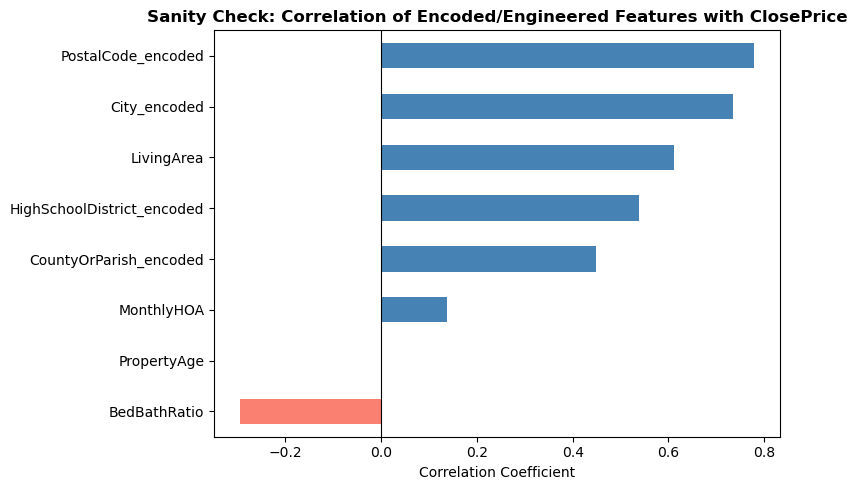

In [33]:
# Quick correlation sanity check: engineered/encoded features vs ClosePrice
# NOTE: DaysOnMarket and ListPrice removed from this check -- excluded from model inputs.
sanity_features = [
    'LivingArea', 'BedBathRatio', 'PropertyAge',
    'PostalCode_encoded', 'City_encoded', 'CountyOrParish_encoded',
    'HighSchoolDistrict_encoded', 'MonthlyHOA',
]
sanity_features = [c for c in sanity_features if c in train_df.columns]

corr_check = train_df[sanity_features + ['ClosePrice']].corr()['ClosePrice'].drop('ClosePrice')
corr_check = corr_check.sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr_check.plot(kind='barh', ax=ax, color=corr_check.map(lambda x: 'steelblue' if x > 0 else 'salmon'))
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Sanity Check: Correlation of Encoded/Engineered Features with ClosePrice', fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

---
## 10. Save Engineered Train / Test Split (For Week 5+ Modelling)

`sfr_baseline_train.csv` / `sfr_baseline_test.csv` (raw fields only, no engineered features)
were already saved at the checkpoint in Section 5b -- those are the files the Week 4 baseline
model reads from.

The train/test split below **does** include engineered features, encodings, and scaling,
since it is intended for Week 5+ once the baseline has been established. Saved to separate
files so it never overwrites the raw baseline checkpoint.

In [34]:
CLEANED_DIR = Path('../data/cleaned')
CLEANED_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(CLEANED_DIR / 'sfr_train.csv', index=False)
test_df.to_csv(CLEANED_DIR / 'sfr_test.csv', index=False)
print(f'Saved: {CLEANED_DIR / "sfr_train.csv"}  ({train_df.shape[0]:,} rows, {train_df.shape[1]} columns)')
print(f'Saved: {CLEANED_DIR / "sfr_test.csv"}   ({test_df.shape[0]:,} rows, {test_df.shape[1]} columns)')
print()
print('Reminder: sfr_baseline_train.csv / sfr_baseline_test.csv (Section 5b) contain NO')
print('engineered features and are the files used for the Week 4 baseline model.')

Saved: ../data/cleaned/sfr_train.csv  (58,805 rows, 159 columns)
Saved: ../data/cleaned/sfr_test.csv   (11,909 rows, 159 columns)

Reminder: sfr_baseline_train.csv / sfr_baseline_test.csv (Section 5b) contain NO
engineered features and are the files used for the Week 4 baseline model.


---
## 11. Preprocessing Summary (v2 — Leakage-Safe)

### Fields Dropped (19 total)
100% null: `AboveGradeFinishedArea`, `BelowGradeFinishedArea`, `BuildingAreaTotal`, `TaxAnnualAmount`,
`TaxYear`, `CoveredSpaces`, `FireplacesTotal`, `BusinessType`, `ElementarySchoolDistrict`,
`MiddleOrJuniorSchoolDistrict`

Sparse/redundant: `WaterfrontYN`, `BasementYN`, `ElementarySchool`, `MiddleOrJuniorSchool`, `HighSchool`,
`LotSizeAcres`, `LotSizeArea`, `LotSizeDimensions`, `MainLevelBedrooms`

### What Changed From v1

| Issue | v1 (previous) | v2 (this notebook) |
|---|---|---|
| Train/test split timing | Happened late (Section 7), after imputation/engineering | Happens immediately after structural row drops (Section 3) |
| ClosePrice outlier thresholds | Fixed heuristic ($10k floor), applied to full dataset pre-split | 0.5th/99.5th percentile, **learned from train only**, frozen cutoffs applied to test |
| Imputation statistics (medians/modes) | Computed on full 7-month dataset | Computed on `train_df` only, applied to `test_df` |
| Flooring type frequency threshold | Computed on full dataset | Computed on `train_df` only |
| Log-transform skew decision | Computed on full dataset | Computed on `train_df` only |
| `DaysOnMarket`, `PriceReductionYN` | Included as feature candidates | **Excluded** per leakage audit (reflect post-sale pricing decisions) |
| Baseline CSV | Single `sfr_cleaned.csv`, pre-split | `sfr_baseline_train.csv` / `sfr_baseline_test.csv`, split preserved |

### Rows Dropped
- `LivingArea == 0` (structural error, hard rule, pre-split): a small number of rows
- `ClosePrice` outside train-derived [0.5th, 99.5th] percentile range (post-split, per-split counts logged in Section 4)

### Imputation Summary (all fit on train only where data-derived)

| Field | Strategy |
|---|---|
| Boolean amenities (Pool, View, Fireplace, AttachedGarage, NewConstruction) | Impute `False` (constant) |
| `GarageSpaces`, `ParkingTotal` | Impute `0` (constant) |
| `AssociationFee` / `AssociationFeeFrequency` | Impute `0` / `'None'` (constant, no HOA) |
| `LotSizeSquareFeet` | ZIP median -> county median -> global median, **learned from train** |
| `Stories` | Mode, **learned from train** |
| `YearBuilt` | Median, **learned from train** |
| `Flooring` | `'Unknown'` (constant) |
| `Levels` | Mode, **learned from train** |
| `HighSchoolDistrict` | **Left null** -- filled via Week 6 spatial join |

### Leakage-Excluded Fields (Model Inputs)
`ListPrice`, `OriginalListPrice`, `DaysOnMarket`, `PriceReductionYN` -- all four only exist
because a sale process happened, and are excluded from `MODEL_FEATURES_PREVIEW` (Section 9).
They remain in the dataframe for diagnostic use only (e.g. `SaleToListRatio`, `PricePerSqFt`).

### Encoding & Scaling Strategy (Sections 7-8 -- Week 5+ only)
- **Ordinal:** `Levels_primary` -> `Levels_encoded`
- **One-hot:** `CountyOrParish` (60 categories), fit on train, columns aligned to test
- **Target (mean) encoding, train-fit only:** `PostalCode`, `City`, `HighSchoolDistrict`
- **Scaling:** `StandardScaler` fit on training data only, applied to both splits

### Train / Test Split
- **Test set:** most recent month (May 2026)
- **Training set:** X months immediately preceding, where X is tunable (`build_train_test_split`
  function supports X = 1 through 6)
- **Next step (Week 4):** experimentally evaluate model performance across X = 2, 3, 4, 5, 6 to
  select the optimal training window length, using the raw-field baseline model

### Remaining Known Gaps (Not Yet Addressed, Lower Priority)
- No validation month carved out of training for hyperparameter tuning (train/test only so far)
- No rolling-origin backtest across multiple historical cutoffs
- No duplicate-listing or CloseDate-before-ListingContractDate checks
- Preprocessing not yet wrapped in a formal sklearn `Pipeline`/`ColumnTransformer`
- No fixed random seeds project-wide, no `requirements.txt`, no data-snapshot version note

### Deliverables
- `notebooks/02_preprocessing.ipynb` (this notebook, v2)
- `data/cleaned/sfr_baseline_train.csv` / `sfr_baseline_test.csv` -- **raw/cleaned fields only, zero engineered features, leakage-safe split (Week 4 baseline input)**
- `data/cleaned/sfr_train.csv` / `sfr_test.csv` -- engineered + encoded + scaled, leakage-safe (Week 5+)